In [1]:
import glob
import os
import sys
import re
import pandas as pd

import matplotlib.pyplot as plt


In [4]:

def parse_ddp_logs(file_path):
    data = []
    # Extract metadata from filename
    # stdout-node-0-gb-1-param-1048576.log
    filename = file_path.split('/')[-1]
    meta = re.search(r'node-(\d+)-gb-(\d+)-param-(\d+)', filename)
    rank, gb_enabled, total_params = meta.groups()

    with open(file_path, 'r') as f:
        current_epoch = None
        for line in f:
            # 1. Capture the start of the finalize process
            if "FINALIZE_START" in line:
                ts = int(line.split(',')[-1])
                data.append({
                    'rank': rank, 'gb': gb_enabled, 'params': total_params,
                    'event': 'FINALIZE_START', 'ts': ts
                })
            
            # 2. Capture when individual buckets resolve
            elif "BUCKET_RESOLVED" in line:
                _, b_idx, ts = line.strip().split(',')
                data.append({
                    'rank': rank, 'gb': gb_enabled, 'params': total_params,
                    'event': f'BUCKET_{b_idx}_READY', 'ts': int(ts)
                })

            # 3. Capture the absolute end
            elif "FINALIZE_END" in line:
                ts = int(line.split(',')[-1])
                data.append({
                    'rank': rank, 'gb': gb_enabled, 'params': total_params,
                    'event': 'FINALIZE_END', 'ts': ts
                })

    return pd.DataFrame(data)

# Usage in Notebook:
log_files = glob.glob("./data/20260216_041416/stdout-node-*.log")
all_dfs = [parse_ddp_logs(f) for f in log_files]
df = pd.concat(all_dfs)

# Calculate "Stall Time" (Time CPU spent waiting for NCCL in finalize)
pivot = df.pivot_table(index=['params', 'gb'], columns='event', values='ts')
pivot['stall_ms'] = (pivot['FINALIZE_END'] - pivot['FINALIZE_START']) / 1e6 # Convert ns to ms
print(pivot[['stall_ms']])

event        stall_ms
params   gb          
1048576  0   0.586240
         1   0.182016
16777216 0   2.072576
         1   0.380928
2097152  0   0.914944
         1   0.243968
262144   0   0.266752
         1   0.097536
33554432 0   3.926784
         1   0.727040
4194304  0   1.291008
         1   0.281344
524288   0   0.409600
         1   0.152320
67108864 0   7.801856
         1   1.468672
8388608  0   1.570048
         1   0.327424


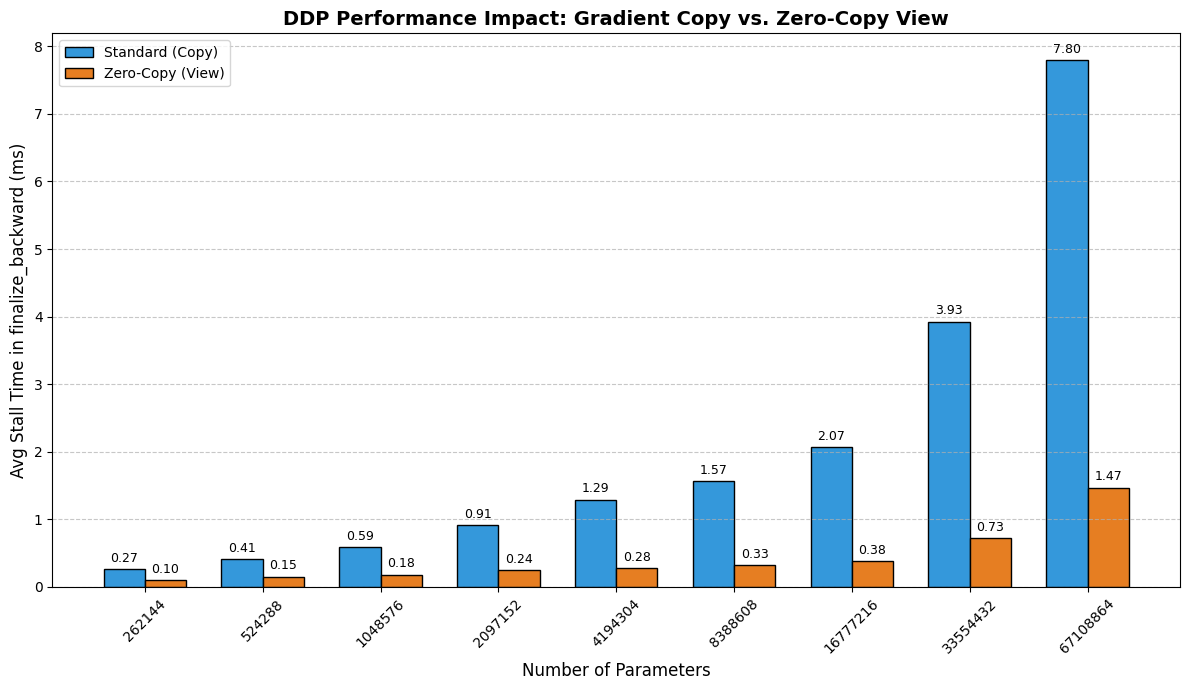

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
import glob

def parse_ddp_logs(file_path):
    data = []
    filename = file_path.split('/')[-1]
    meta = re.search(r'node-(\d+)-gb-(\d+)-param-(\d+)', filename)
    if not meta: return pd.DataFrame()
    
    rank, gb_enabled, total_params = meta.groups()

    with open(file_path, 'r') as f:
        for line in f:
            if "FINALIZE_START" in line:
                ts = int(line.split(',')[-1])
                data.append({'gb': int(gb_enabled), 'params': int(total_params), 'event': 'START', 'ts': ts})
            elif "FINALIZE_END" in line:
                ts = int(line.split(',')[-1])
                data.append({'gb': int(gb_enabled), 'params': int(total_params), 'event': 'END', 'ts': ts})
    return pd.DataFrame(data)

# 1. Load and Process Data
log_files = glob.glob("./data/20260216_041416/stdout-node-*.log")
df = pd.concat([parse_ddp_logs(f) for f in log_files])

# We need to pair START and END to calculate duration, then average by params/gb
# This assumes logs are sequential (START followed by END)
df['stall_ms'] = df.groupby(['params', 'gb'])['ts'].diff() / 1e6
stats = df[df['event'] == 'END'].groupby(['params', 'gb'])['stall_ms'].mean().unstack()

# 2. Setup Plotting Data
params_labels = stats.index.astype(str).tolist()
copy_means = stats[0].fillna(0).tolist()
view_means = stats[1].fillna(0).tolist()

x = np.arange(len(params_labels))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, copy_means, width, label='Standard (Copy)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, view_means, width, label='Zero-Copy (View)', color='#e67e22', edgecolor='black')

# 3. Customization
ax.set_ylabel('Avg Stall Time in finalize_backward (ms)', fontsize=12)
ax.set_xlabel('Number of Parameters', fontsize=12)
ax.set_title('DDP Performance Impact: Gradient Copy vs. Zero-Copy View', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(params_labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [2]:
def parse_ddp_logs2(file_path):
    """Parse DDP backward timing logs."""
    copy_times = []
    comm_times = []
    data = []
    filename = file_path.split('/')[-1]
    meta = re.search(r'node-(\d+)-gb-(\d+)-param-(\d+)', filename)
    if not meta: return pd.DataFrame()
    
    rank, gb_enabled, total_params = meta.groups()

    with open(file_path, 'r') as f:
        for line in f:
            if 'DDP_BACKWARD:' in line:
                # Extract copy=XXXus, comm=YYYus
                copy_match = re.search(r'copy=(\d+)us', line)
                if copy_match:
                    data.append({'gb': int(gb_enabled), 'params': int(total_params), 'copy': int(copy_match.group(1))})
    
    return pd.DataFrame(data)

def parse_ddp_logs3(file_path):
    """Parse DDP backward timing logs."""
    copy_times = []
    comm_times = []
    data = []
    filename = file_path.split('/')[-1]
    meta = re.search(r'node-(\d+)-gb-(\d+)-param-(\d+)', filename)
    if not meta: return pd.DataFrame()
    
    rank, gb_enabled, total_params = meta.groups()

    with open(file_path, 'r') as f:
        for line in f:
            if 'ALLREDUCE' in line:
                # Extract copy=XXXus, comm=YYYus
                copy_match = re.search(r'=\s*(\d+)\s*us', line)
                if copy_match:
                    data.append({'gb': int(gb_enabled), 'params': int(total_params), 'comm': int(copy_match.group(1))})
    
    return pd.DataFrame(data)



In [3]:

# Usage
log_files = glob.glob("./data/20260216_143615/stdout-node-*.log")
df = pd.concat([parse_ddp_logs2(f) for f in log_files])
df.head()

,gb,params,copy
0,1,262144,31
1,1,262144,104
2,1,262144,5
3,1,262144,4
4,1,262144,5


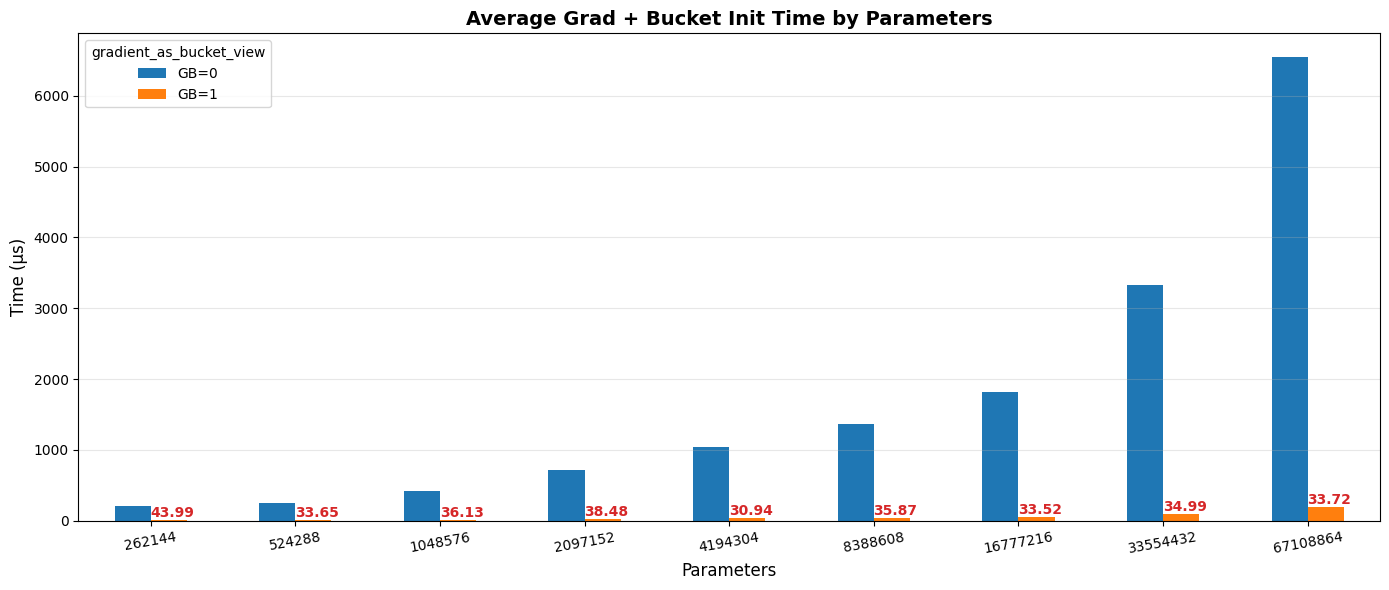

In [4]:

# Assuming df is your dataframe with columns: gb, params, copy, comm

# Calculate averages for each params + gb combination
avg_data = df.groupby(['params', 'gb']).agg({
    'copy': 'mean',
}).reset_index()

# Pivot for plotting
copy_pivot = avg_data.pivot(index='params', columns='gb', values='copy')

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot 1: Copy times
copy_pivot.plot(kind='bar', ax=axes, color=['#1f77b4', '#ff7f0e'])
axes.set_title('Average Grad + Bucket Time by Parameters', fontsize=14, fontweight='bold')
axes.set_xlabel('Parameters', fontsize=12)
axes.set_ylabel('Time (μs)', fontsize=12)
axes.legend(['GB=0', 'GB=1'], title='gradient_as_bucket_view')
axes.grid(axis='y', alpha=0.3)
axes.tick_params(axis='x', rotation=10)

# Calculate factor improvement and annotate
for i, (p0, p1) in enumerate(zip(copy_pivot[0], copy_pivot[1])):
    factor = p0 / p1
    axes.text(i + 0.15, p1 + (p1 * 0.02), f'{factor:.2f}', 
              ha='center', va='bottom', fontweight='bold', color='#d62728')
    
plt.tight_layout()
plt.savefig('ddp_timing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

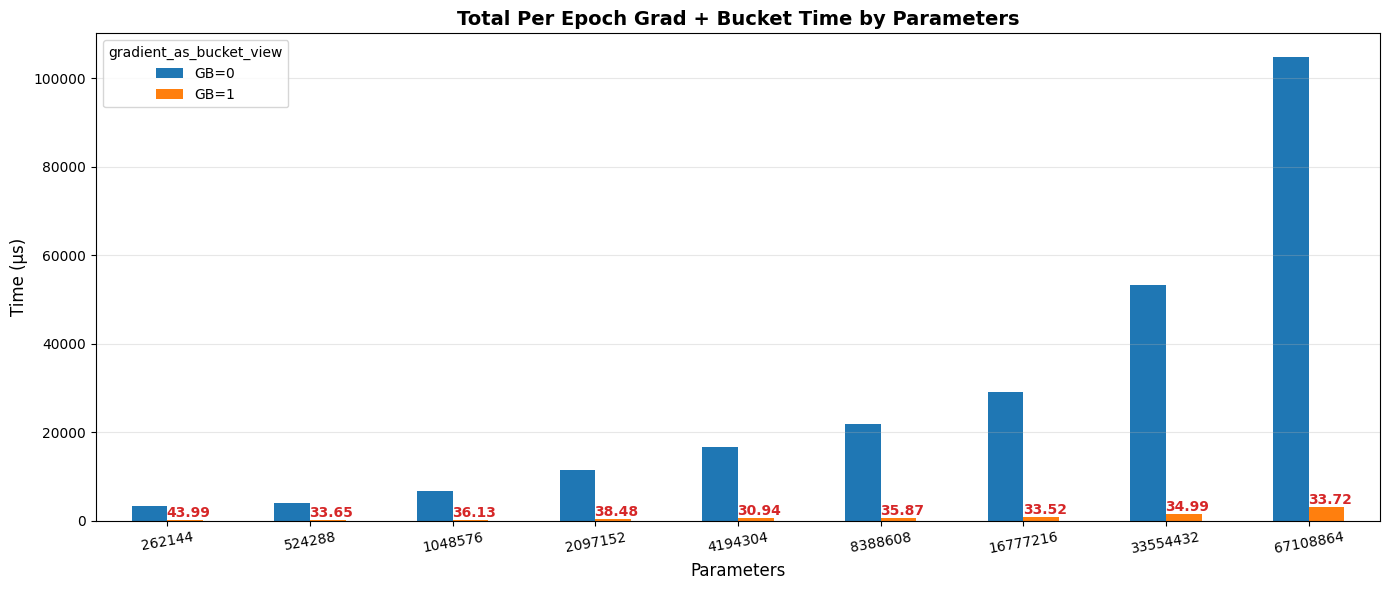

In [6]:

# Calculate total epoch time for each params + gb combination 
NUM_EPOCHS = 20
avg_data = df.groupby(['params', 'gb']).agg({
    'copy': 'sum',
}).reset_index()

# Pivot for plotting
copy_pivot = avg_data.pivot(index='params', columns='gb', values='copy')
copy_pivot = copy_pivot.div(NUM_EPOCHS) 

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot 1: Copy times
copy_pivot.plot(kind='bar', ax=axes, color=['#1f77b4', '#ff7f0e'])
axes.set_title('Total Per Epoch Grad + Bucket Time by Parameters', fontsize=14, fontweight='bold')
axes.set_xlabel('Parameters', fontsize=12)
axes.set_ylabel('Time (μs)', fontsize=12)
axes.legend(['GB=0', 'GB=1'], title='gradient_as_bucket_view')
axes.grid(axis='y', alpha=0.3)
axes.tick_params(axis='x', rotation=10)

# Calculate factor improvement and annotate
for i, (p0, p1) in enumerate(zip(copy_pivot[0], copy_pivot[1])):
    factor = p0 / p1
    axes.text(i + 0.15, p1 + (p1 * 0.02), f'{factor:.2f}', 
              ha='center', va='bottom', fontweight='bold', color='#d62728')
    
plt.tight_layout()
plt.savefig('ddp_timing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 20260216_153455
log_files = glob.glob("./data/20260216_153455/stdout-node-*.log")
df = pd.concat([parse_ddp_logs2(f) for f in log_files])
df.head()

,gb,params,copy
0,0,67108864,10227
1,0,67108864,7883
2,0,67108864,6552
3,0,67108864,6517
4,0,67108864,6672


In [22]:
log_files = glob.glob("./data/20260216_153455/stdout-node-*.log")
df = pd.concat([parse_ddp_logs3(f) for f in log_files])
df.head()

,gb,params,comm
0,0,67108864,73
1,0,67108864,104
2,0,67108864,64
3,0,67108864,37
4,0,67108864,36


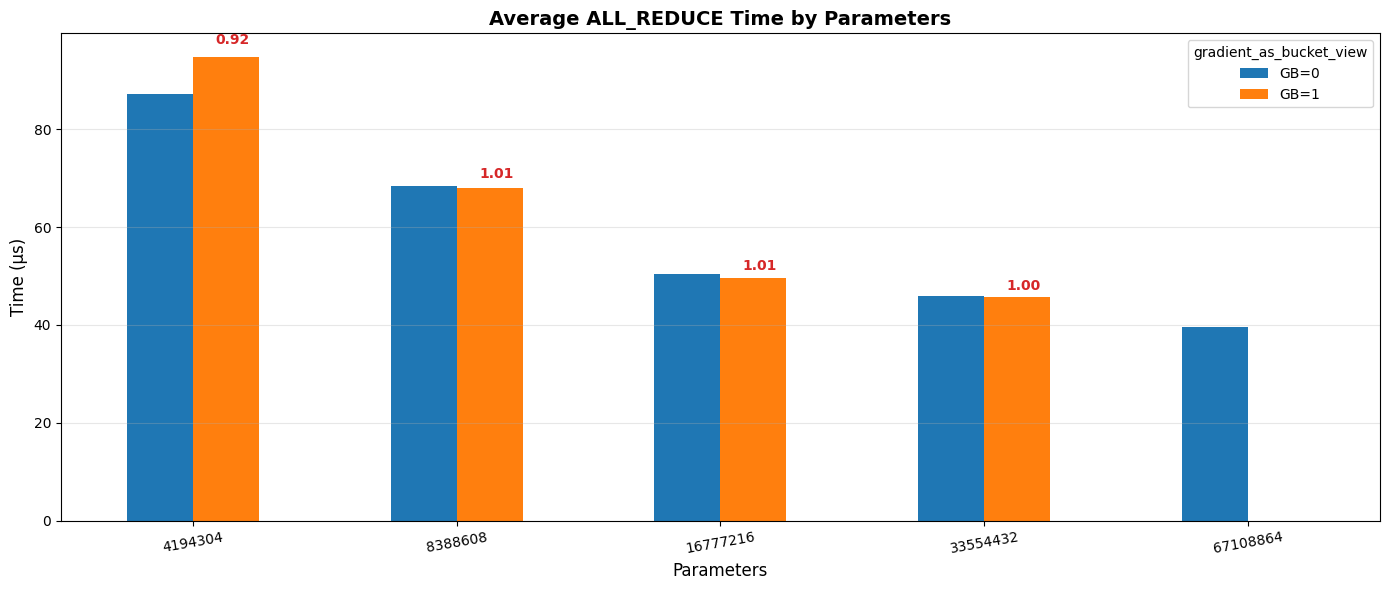

In [23]:
avg_data = df.groupby(['params', 'gb']).agg({
    'comm': 'mean',
}).reset_index()

# Pivot for plotting
copy_pivot = avg_data.pivot(index='params', columns='gb', values='comm')

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot 1: Copy times
copy_pivot.plot(kind='bar', ax=axes, color=['#1f77b4', '#ff7f0e'])
axes.set_title('Average ALL_REDUCE Time by Parameters', fontsize=14, fontweight='bold')
axes.set_xlabel('Parameters', fontsize=12)
axes.set_ylabel('Time (μs)', fontsize=12)
axes.legend(['GB=0', 'GB=1'], title='gradient_as_bucket_view')
axes.grid(axis='y', alpha=0.3)
axes.tick_params(axis='x', rotation=10)

# Calculate factor improvement and annotate
for i, (p0, p1) in enumerate(zip(copy_pivot[0], copy_pivot[1])):
    factor = p0 / p1
    axes.text(i + 0.15, p1 + (p1 * 0.02), f'{factor:.2f}', 
              ha='center', va='bottom', fontweight='bold', color='#d62728')
    
plt.tight_layout()
plt.savefig('ddp_allreduce_timing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()